In [1]:
import math
import numpy as np


def centering(K):
    n = K.shape[0]
    unit = np.ones([n, n])
    I = np.eye(n)
    H = I - unit / n

    return np.dot(np.dot(H, K), H)  # HKH are the same with KH, KH is the first centering, H(KH) do the second time, results are the sme with one time centering
    # return np.dot(H, K)  # KH


def rbf(X, sigma=None):
    GX = np.dot(X, X.T)
    KX = np.diag(GX) - GX + (np.diag(GX) - GX).T
    if sigma is None:
        mdist = np.median(KX[KX != 0])
        sigma = math.sqrt(mdist)
    KX *= - 0.5 / (sigma * sigma)
    KX = np.exp(KX)
    return KX


def kernel_HSIC(X, Y, sigma):
    return np.sum(centering(rbf(X, sigma)) * centering(rbf(Y, sigma)))


def linear_HSIC(X, Y):
    L_X = np.dot(X, X.T)
    L_Y = np.dot(Y, Y.T)
    return np.sum(centering(L_X) * centering(L_Y))


def linear_CKA(X, Y):
    hsic = linear_HSIC(X, Y)
    var1 = np.sqrt(linear_HSIC(X, X))
    var2 = np.sqrt(linear_HSIC(Y, Y))

    return hsic / (var1 * var2)


def kernel_CKA(X, Y, sigma=None):
    hsic = kernel_HSIC(X, Y, sigma)
    var1 = np.sqrt(kernel_HSIC(X, X, sigma))
    var2 = np.sqrt(kernel_HSIC(Y, Y, sigma))

    return hsic / (var1 * var2)



In [2]:

X = np.random.randn(100, 64)
Y = np.random.randn(100, 64)

print('Linear CKA, between X and Y: {}'.format(linear_CKA(X, Y)))
print('Linear CKA, between X and X: {}'.format(linear_CKA(X, X)))

print('RBF Kernel CKA, between X and Y: {}'.format(kernel_CKA(X, Y)))
print('RBF Kernel CKA, between X and X: {}'.format(kernel_CKA(X, X)))

Linear CKA, between X and Y: 0.3891642537109897
Linear CKA, between X and X: 0.9999999999999998
RBF Kernel CKA, between X and Y: 0.5203652568952717
RBF Kernel CKA, between X and X: 1.0


In [3]:
def compute_cka_matrix(hidden_states_list):
    """
    hidden_states_list: list of arrays
        length = num_layers
        each shape = (B, L, D)

    returns:
        cka_matrix (num_layers, num_layers)
    """

    num_layers = len(hidden_states_list)
    B = hidden_states_list[0].shape[0]

    cka_matrix = np.zeros((num_layers, num_layers))

    for i in range(num_layers):
        for j in range(i, num_layers):

            scores = []

            for b in range(B):
                X = hidden_states_list[i][b]   # (L, D)
                Y = hidden_states_list[j][b]   # (L, D)

                score = linear_CKA(X, Y)
                scores.append(score)

            cka = np.mean(scores)

            cka_matrix[i, j] = cka
            cka_matrix[j, i] = cka

    return cka_matrix

import matplotlib.pyplot as plt
import numpy as np

def plot_cka_heatmap(cka_matrix):
    n = cka_matrix.shape[0]

    plt.figure(figsize=(30,30))

    im = plt.imshow(cka_matrix, vmin=0, vmax=1)

    plt.colorbar(im)

    labels = [f"L{i}" for i in range(n)]
    plt.xticks(range(n), labels)
    plt.yticks(range(n), labels)

    plt.xlabel("Layer")
    plt.ylabel("Layer")
    plt.title("CKA Layer Similarity")

    # add numbers
    for i in range(n):
        for j in range(n):
            value = cka_matrix[i, j]
            plt.text(j, i, f"{value:.2f}",
                     ha="center",
                     va="center",
                     fontsize=20,
                     color="black" if value > 0.5 else "white")

    plt.tight_layout()
    plt.show()
 

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

def plot_cka_heatmap_paper_style(cka_matrix):
    n = cka_matrix.shape[0]

    fig, ax = plt.subplots(figsize=(4, 4))

    im = ax.imshow(
        cka_matrix,
        cmap="RdBu_r",   # red (high) → white → blue (low), matches paper
        vmin=0,
        vmax=1,
        aspect="auto",
        interpolation="nearest",
    )

    # Colorbar — slim, tight to the right
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=6)

    # Axis ticks: show every other layer to avoid crowding
    tick_step = max(1, n // 12)
    ticks = list(range(0, n, tick_step))
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(ticks, fontsize=6)
    ax.set_yticklabels(ticks, fontsize=6)

    ax.tick_params(axis="both", length=2, pad=2)

    # No axis labels (paper style omits xlabel/ylabel on these subplots)
    ax.set_xlabel("")
    ax.set_ylabel("")

    plt.tight_layout()
    plt.savefig("cka_heatmap.pdf", dpi=300, bbox_inches="tight")
    plt.show()

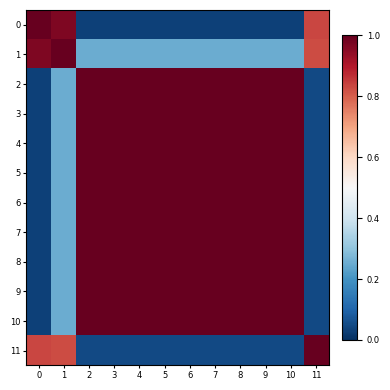

In [5]:
# chosen_module = "dit"
chosen_module = 'vlm'
# chosen_module = "vl_self_attn"

import os

hs_root = "/home/jibby/Workspace/research/prunner/attn_pi0/old/attn_gr15/hs"

hs_dir = f"{hs_root}/{chosen_module}"
# n_embs = [0, 1]
n_layers = list(range(len(os.listdir(hs_dir))))
list_hs = []
for i in n_layers:
    try:
        if i != 0:  # skip layer 0 for dit, since it's all zeros
            list_hs.append(np.load(f"{hs_dir}/layer_{i}.npy"))
    except FileNotFoundError:
        print(f"File not found for layer {i}")

cka_matrix_vlm= compute_cka_matrix(list_hs)
# plot_cka_heatmap(cka_matrix)
plot_cka_heatmap_paper_style(cka_matrix_vlm)

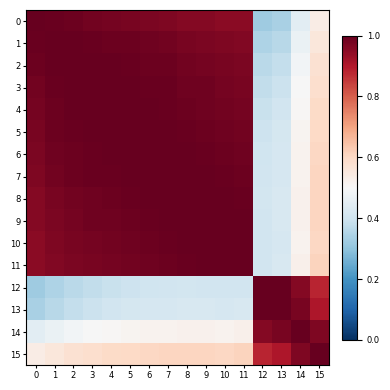

In [6]:
chosen_module = "dit"
# chosen_module = 'vlm'
# chosen_module = "vl_self_attn"

import os

hs_root = "/home/jibby/Workspace/research/prunner/attn_pi0/old/attn_gr15/hs"

hs_dir = f"{hs_root}/{chosen_module}"
# n_embs = [0, 1]
n_layers = list(range(len(os.listdir(hs_dir))))
list_hs = []
for i in n_layers:
    try:
        if i != 0:  # skip layer 0 for dit, since it's all zeros
            list_hs.append(np.load(f"{hs_dir}/layer_{i}.npy"))
    except FileNotFoundError:
        print(f"File not found for layer {i}")

cka_matrix_dit= compute_cka_matrix(list_hs)
# plot_cka_heatmap(cka_matrix)
plot_cka_heatmap_paper_style(cka_matrix_dit)

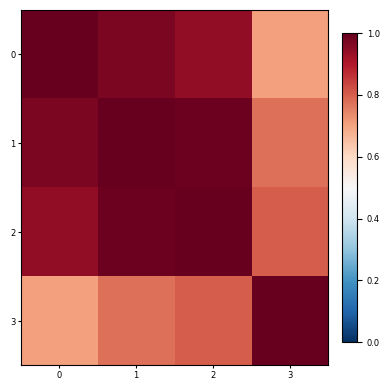

In [7]:
# chosen_module = "dit"
# chosen_module = 'vlm'
chosen_module = "vl_self_attn"

import os

hs_root = "/home/jibby/Workspace/research/prunner/attn_pi0/old/attn_gr15/hs"

hs_dir = f"{hs_root}/{chosen_module}"
# n_embs = [0, 1]
n_layers = list(range(len(os.listdir(hs_dir))))
list_hs = []
for i in n_layers:
    try:
        if i != 0:  # skip layer 0 for vl_self_attn, since it's all zeros
            list_hs.append(np.load(f"{hs_dir}/layer_{i}.npy"))
    except FileNotFoundError:
        print(f"File not found for layer {i}")

cka_matrix_vl_self_attn= compute_cka_matrix(list_hs)
# plot_cka_heatmap(cka_matrix)
plot_cka_heatmap_paper_style(cka_matrix_vl_self_attn)

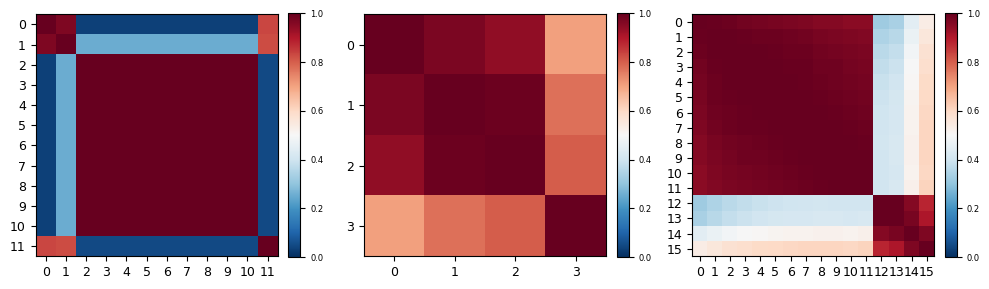

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

for ax, matrix, title in zip(axes, [cka_matrix_vlm, cka_matrix_vl_self_attn, cka_matrix_dit], ["VLM", "VL Self-Attention", "DiT"]):
    im = ax.imshow(matrix, cmap="RdBu_r", vmin=0, vmax=1, aspect="equal")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(labelsize=6)
    # ax.set_title(f"({chr(96 + axes.tolist().index(ax) + 1)}) {title}", fontsize=8)
    n = matrix.shape[0]
    tick_step = max(1, n // 12)
    ticks = list(range(0, n, tick_step))
    ax.set_xticks(ticks); ax.set_yticks(ticks)
    ax.set_xticklabels(ticks, fontsize=9); ax.set_yticklabels(ticks, fontsize=9)

plt.tight_layout()
plt.savefig("cka_comparison.pdf", dpi=300, bbox_inches="tight")

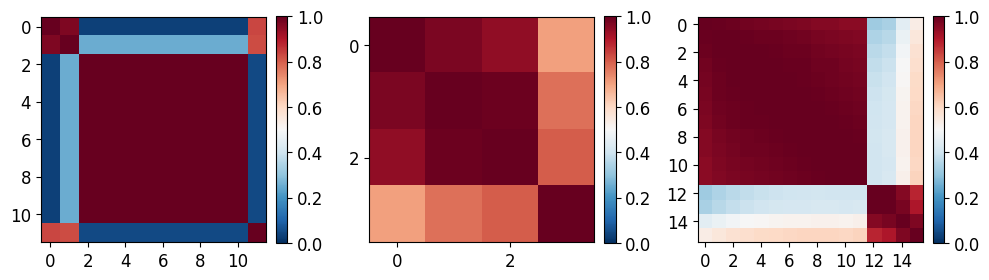

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

for ax, matrix, title in zip(axes, [cka_matrix_vlm, cka_matrix_vl_self_attn, cka_matrix_dit], ["VLM", "VL Self-Attention", "DiT"]):
    im = ax.imshow(matrix, cmap="RdBu_r", vmin=0, vmax=1, aspect="equal")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(labelsize=12)
    n = matrix.shape[0]
    ticks = list(range(0, n, 2))
    ax.set_xticks(ticks); ax.set_yticks(ticks)
    ax.set_xticklabels(ticks, fontsize=12); ax.set_yticklabels(ticks, fontsize=12)

plt.tight_layout()
plt.savefig("cka_comparison.pdf", dpi=300, bbox_inches="tight")

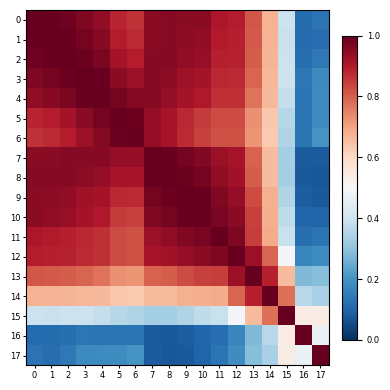

In [9]:
hs_root = "/home/jibby/Workspace/research/prunner/attn_pi0/old/pi0_hs/hs"

# Detect number of layers from filenames
all_files = os.listdir(hs_root)
n_layers = len(set(
    f.split("_emb_")[0] for f in all_files if f.endswith(".npy")
))

list_hs_emb0 = []
list_hs_emb1 = []

for i in range(n_layers):
    try:
        list_hs_emb0.append(np.load(f"{hs_root}/hidden_state_metaworld_{i}_emb_0.npy"))
        list_hs_emb1.append(np.load(f"{hs_root}/hidden_state_metaworld_{i}_emb_1.npy"))
    except FileNotFoundError:
        print(f"File not found for metaworld_{i}")

cka_matrix_emb0 = compute_cka_matrix(list_hs_emb0)
cka_matrix_emb1 = compute_cka_matrix(list_hs_emb1)

plot_cka_heatmap_paper_style(cka_matrix_emb0)  # or add a title param if supported


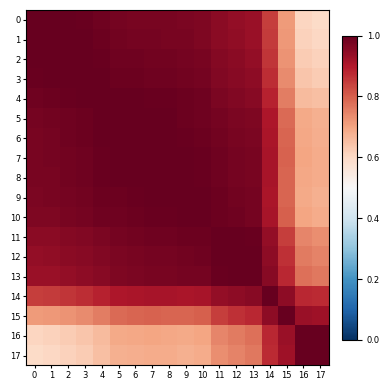

In [10]:
plot_cka_heatmap_paper_style(cka_matrix_emb1)

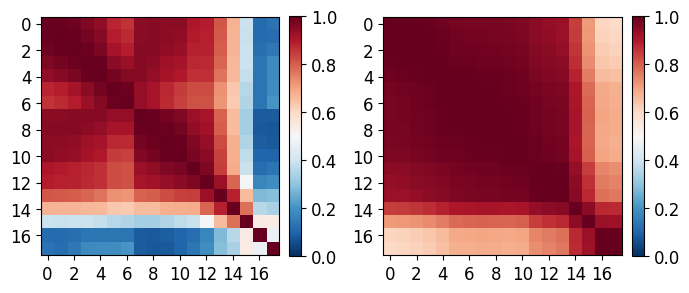

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))

for ax, matrix, title in zip(axes, [cka_matrix_emb0, cka_matrix_emb1], ["VLM", "DiT"]):
    im = ax.imshow(matrix, cmap="RdBu_r", vmin=0, vmax=1, aspect="equal")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(labelsize=12)
    # ax.set_title(title, fontsize=8)
    n = matrix.shape[0]
    tick_step = max(1, n // 12)
    ticks = list(range(0, n, 2))
    ax.set_xticks(ticks); ax.set_yticks(ticks)
    ax.set_xticklabels(ticks, fontsize=12); ax.set_yticklabels(ticks, fontsize=12)

plt.tight_layout()
plt.savefig("cka_comparison_pi0.pdf", dpi=300, bbox_inches="tight")

In [6]:
# chosen_module = "dit"
chosen_module = 'vlm'
# chosen_module = "vl_self_attn"

import os

hs_root = "/home/jibby/Workspace/research/prunner/attn_pi0/gr15_difference_version/attn/gr15_base/hs"

hs_dir = f"{hs_root}/{chosen_module}"
# n_embs = [0, 1]
n_layers = list(range(len(os.listdir(hs_dir))))
list_hs = []
for i in n_layers:
    list_hs.append(np.load(f"{hs_dir}/layer_{i}.npy"))

cka_matrix= compute_cka_matrix(list_hs)
plot_cka_heatmap(cka_matrix)

FileNotFoundError: [Errno 2] No such file or directory: '/home/jibby/Workspace/research/prunner/attn_pi0/gr15_difference_version/attn/gr15_base/hs/vlm/layer_13.npy'

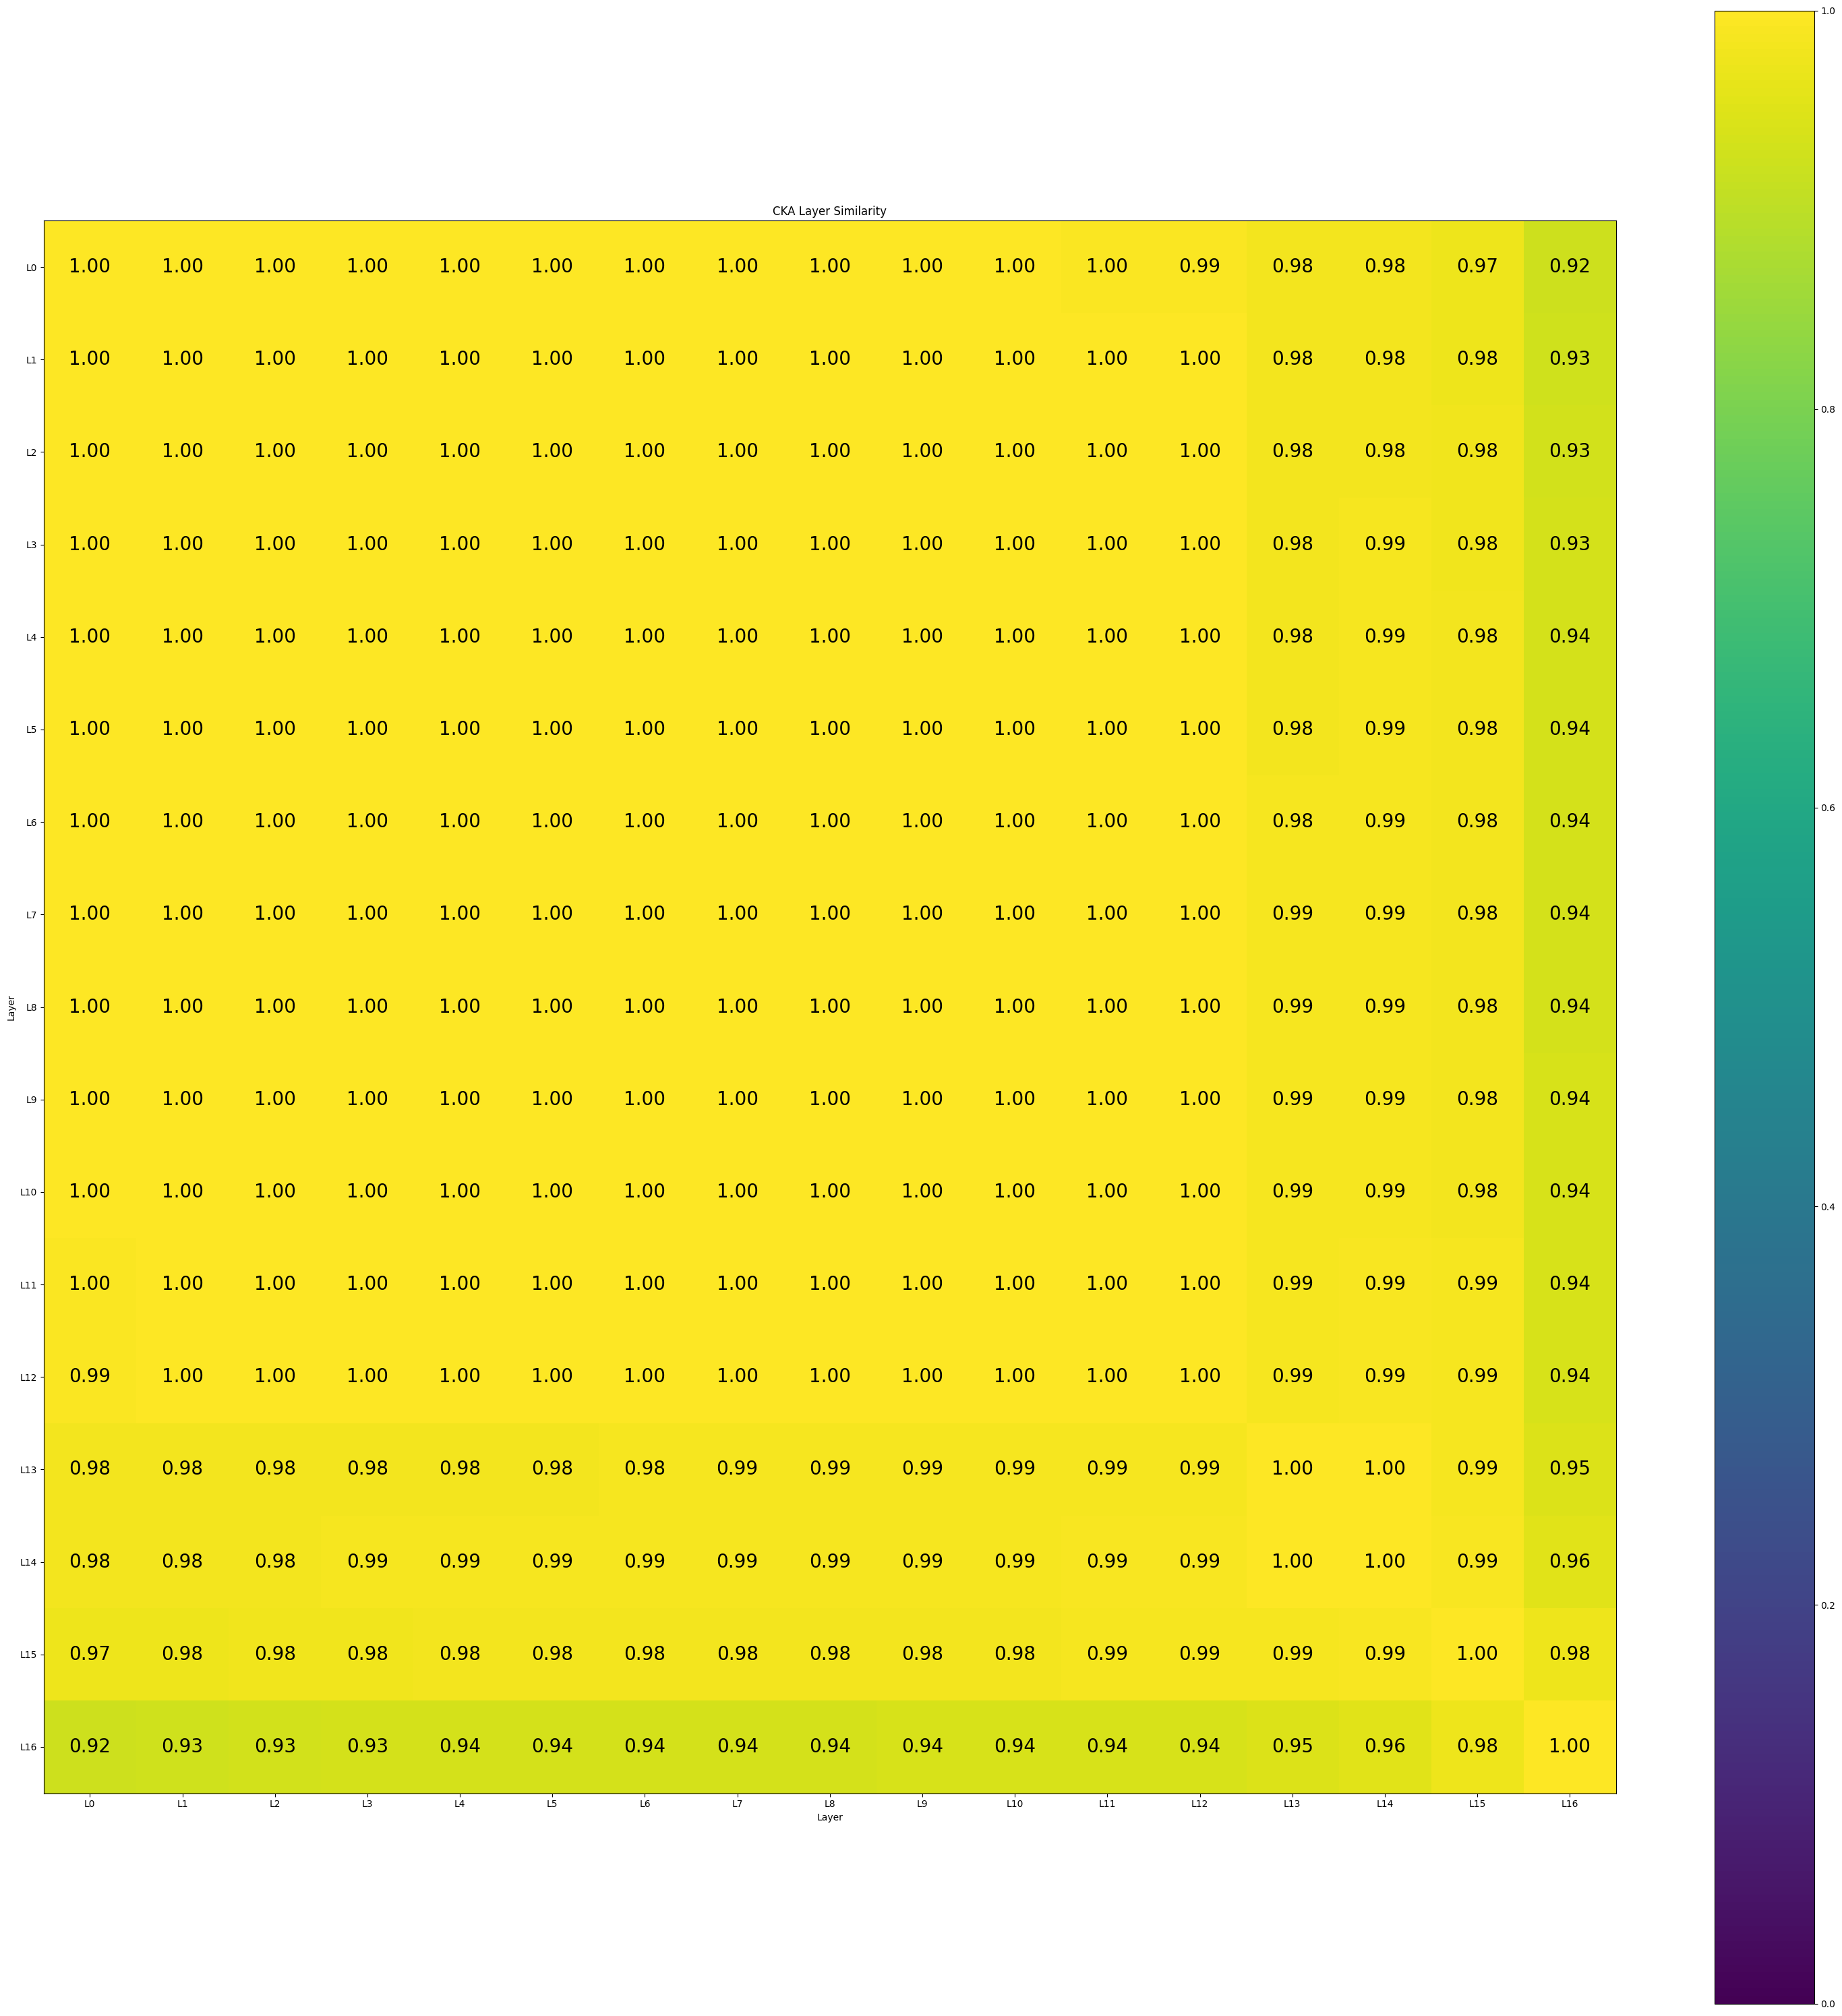

In [14]:
chosen_module = "dit"
# chosen_module = 'vlm'
# chosen_module = "vl_self_attn"

import os

hs_root = "/home/jibby/Workspace/research/prunner/attn_pi0/gr15_difference_version/attn/gr15_base/hs"

hs_dir = f"{hs_root}/{chosen_module}"
# n_embs = [0, 1]
n_layers = list(range(len(os.listdir(hs_dir))))
list_hs = []
for i in n_layers:
    list_hs.append(np.load(f"{hs_dir}/layer_{i}.npy"))

cka_matrix= compute_cka_matrix(list_hs)
plot_cka_heatmap(cka_matrix)

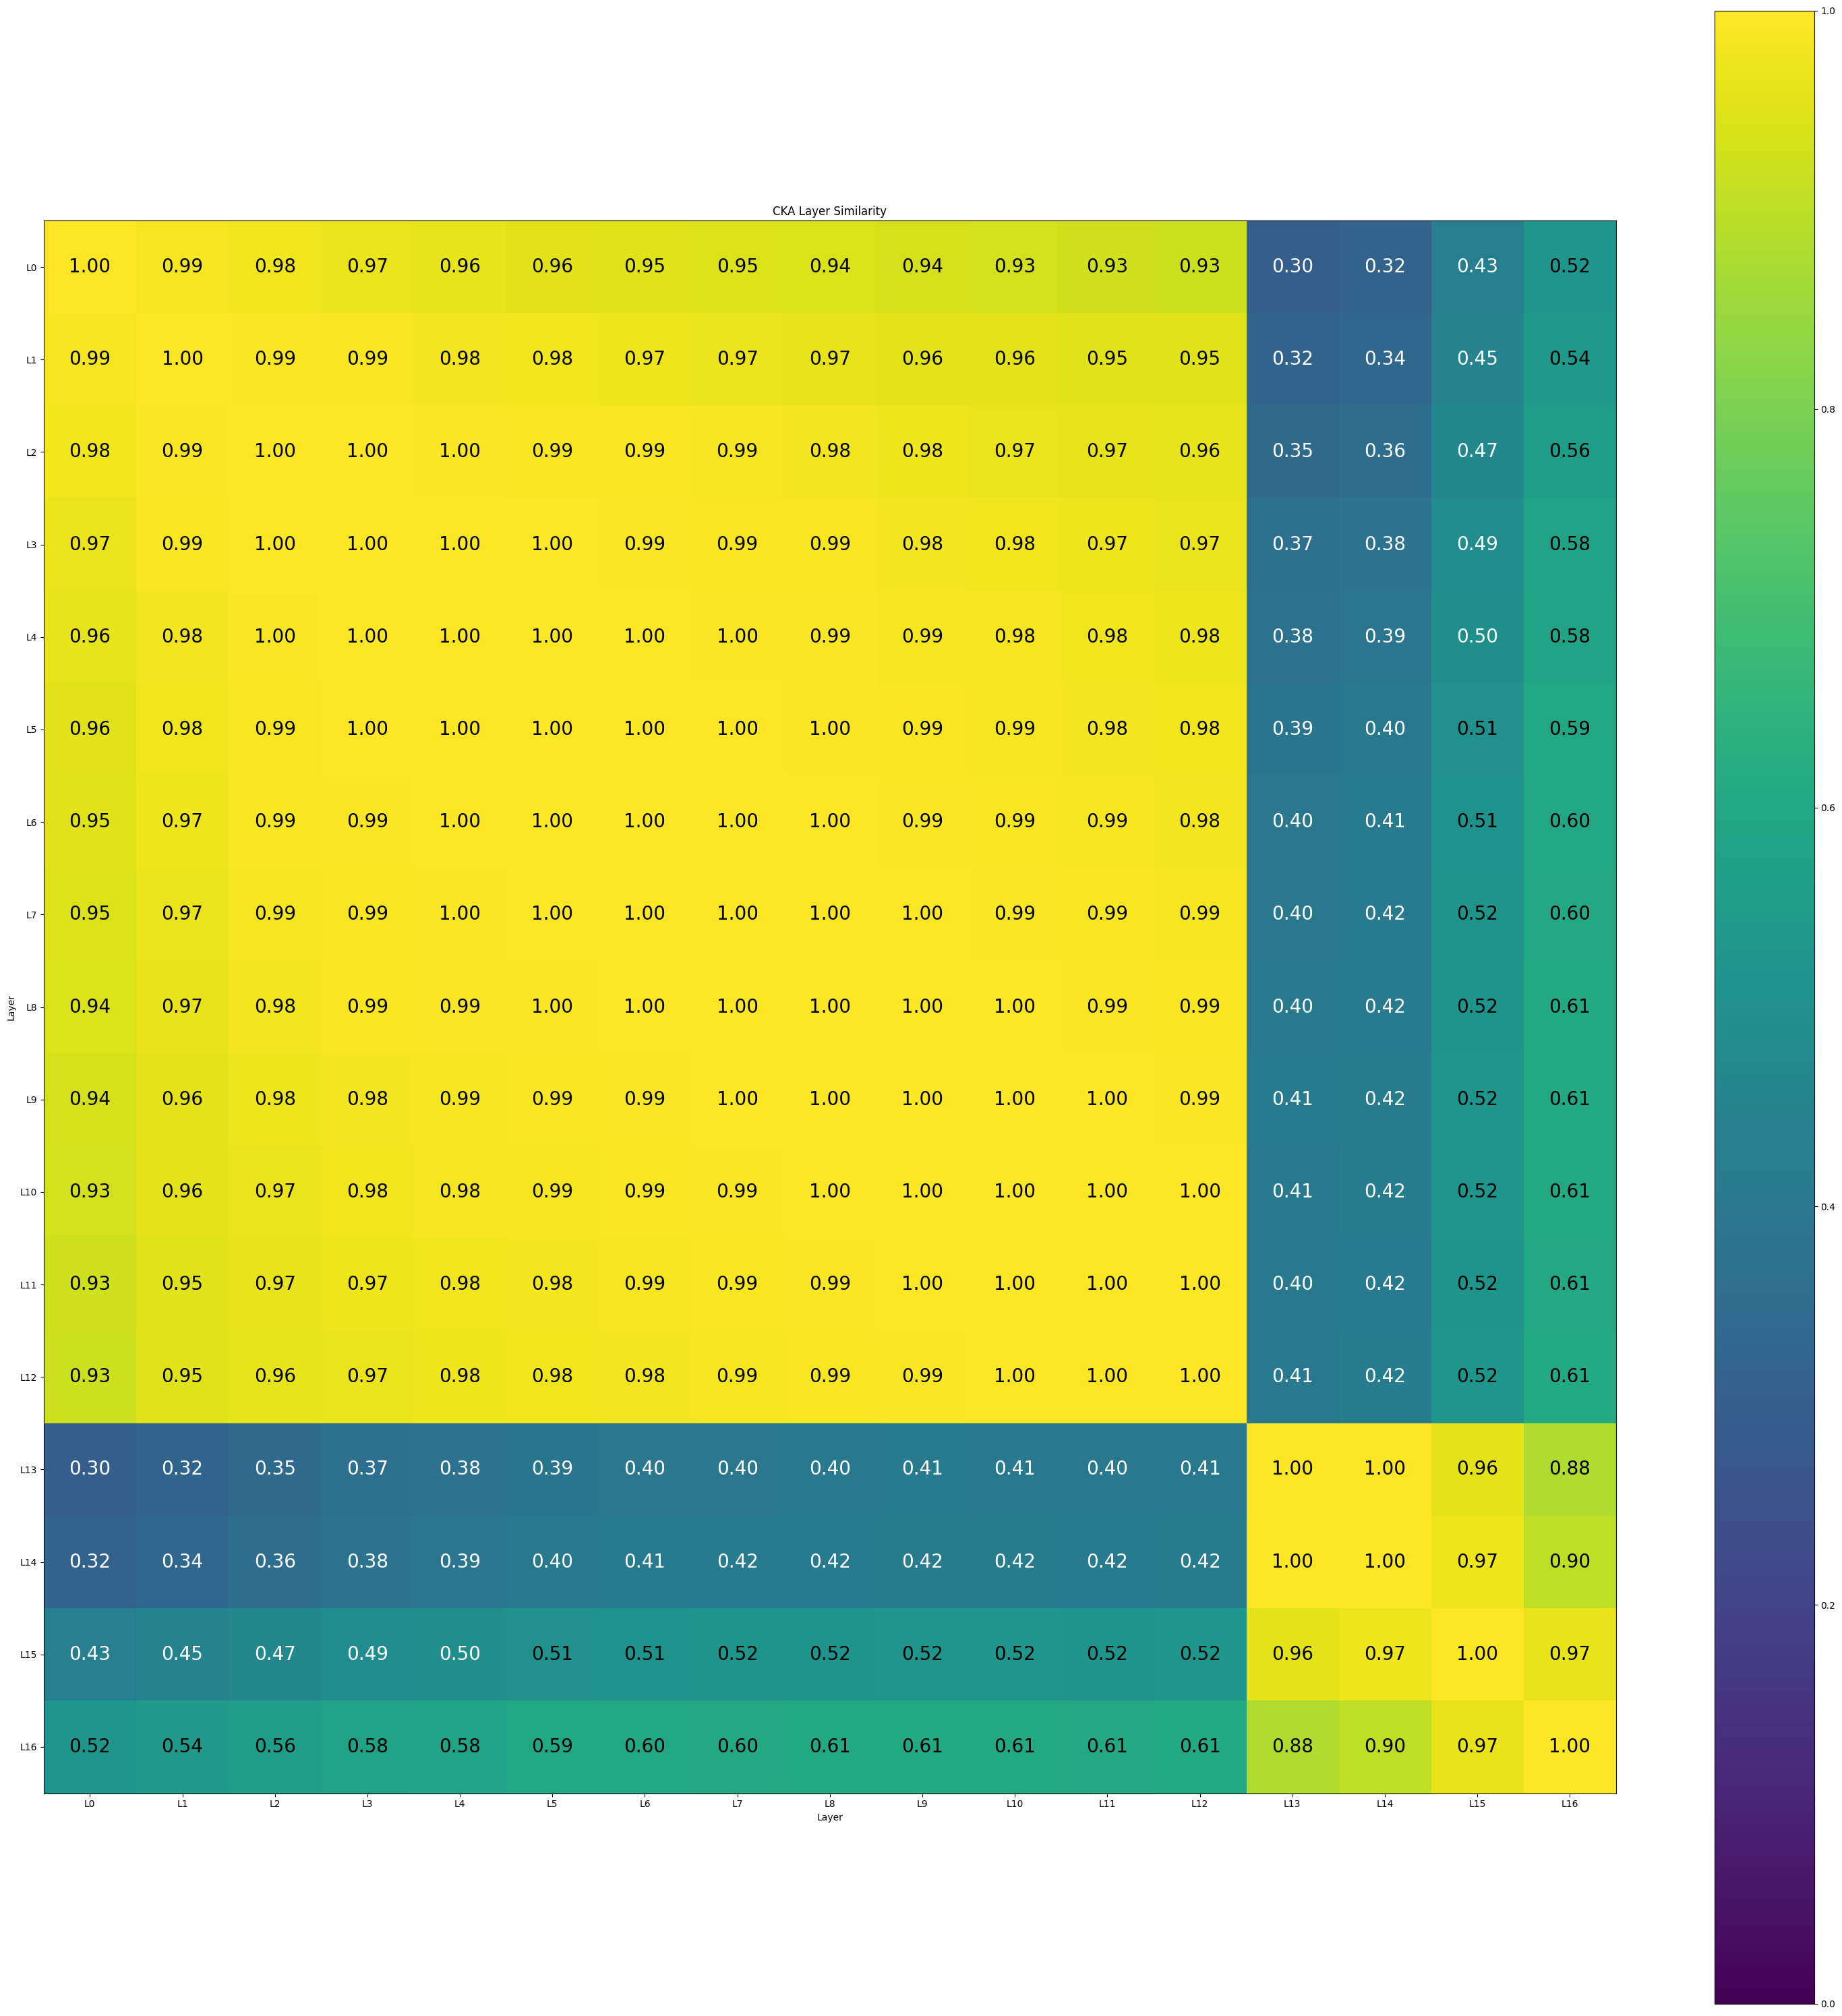

In [12]:
chosen_module = "dit"
# chosen_module = 'vlm'
# chosen_module = "vl_self_attn"

import os

hs_root = "/home/jibby/Workspace/research/prunner/attn_pi0/old/attn_gr15/hs"

hs_dir = f"{hs_root}/{chosen_module}"
# n_embs = [0, 1]
n_layers = list(range(len(os.listdir(hs_dir))))
list_hs = []
for i in n_layers:
    list_hs.append(np.load(f"{hs_dir}/layer_{i}.npy"))

cka_matrix= compute_cka_matrix(list_hs)
plot_cka_heatmap(cka_matrix)

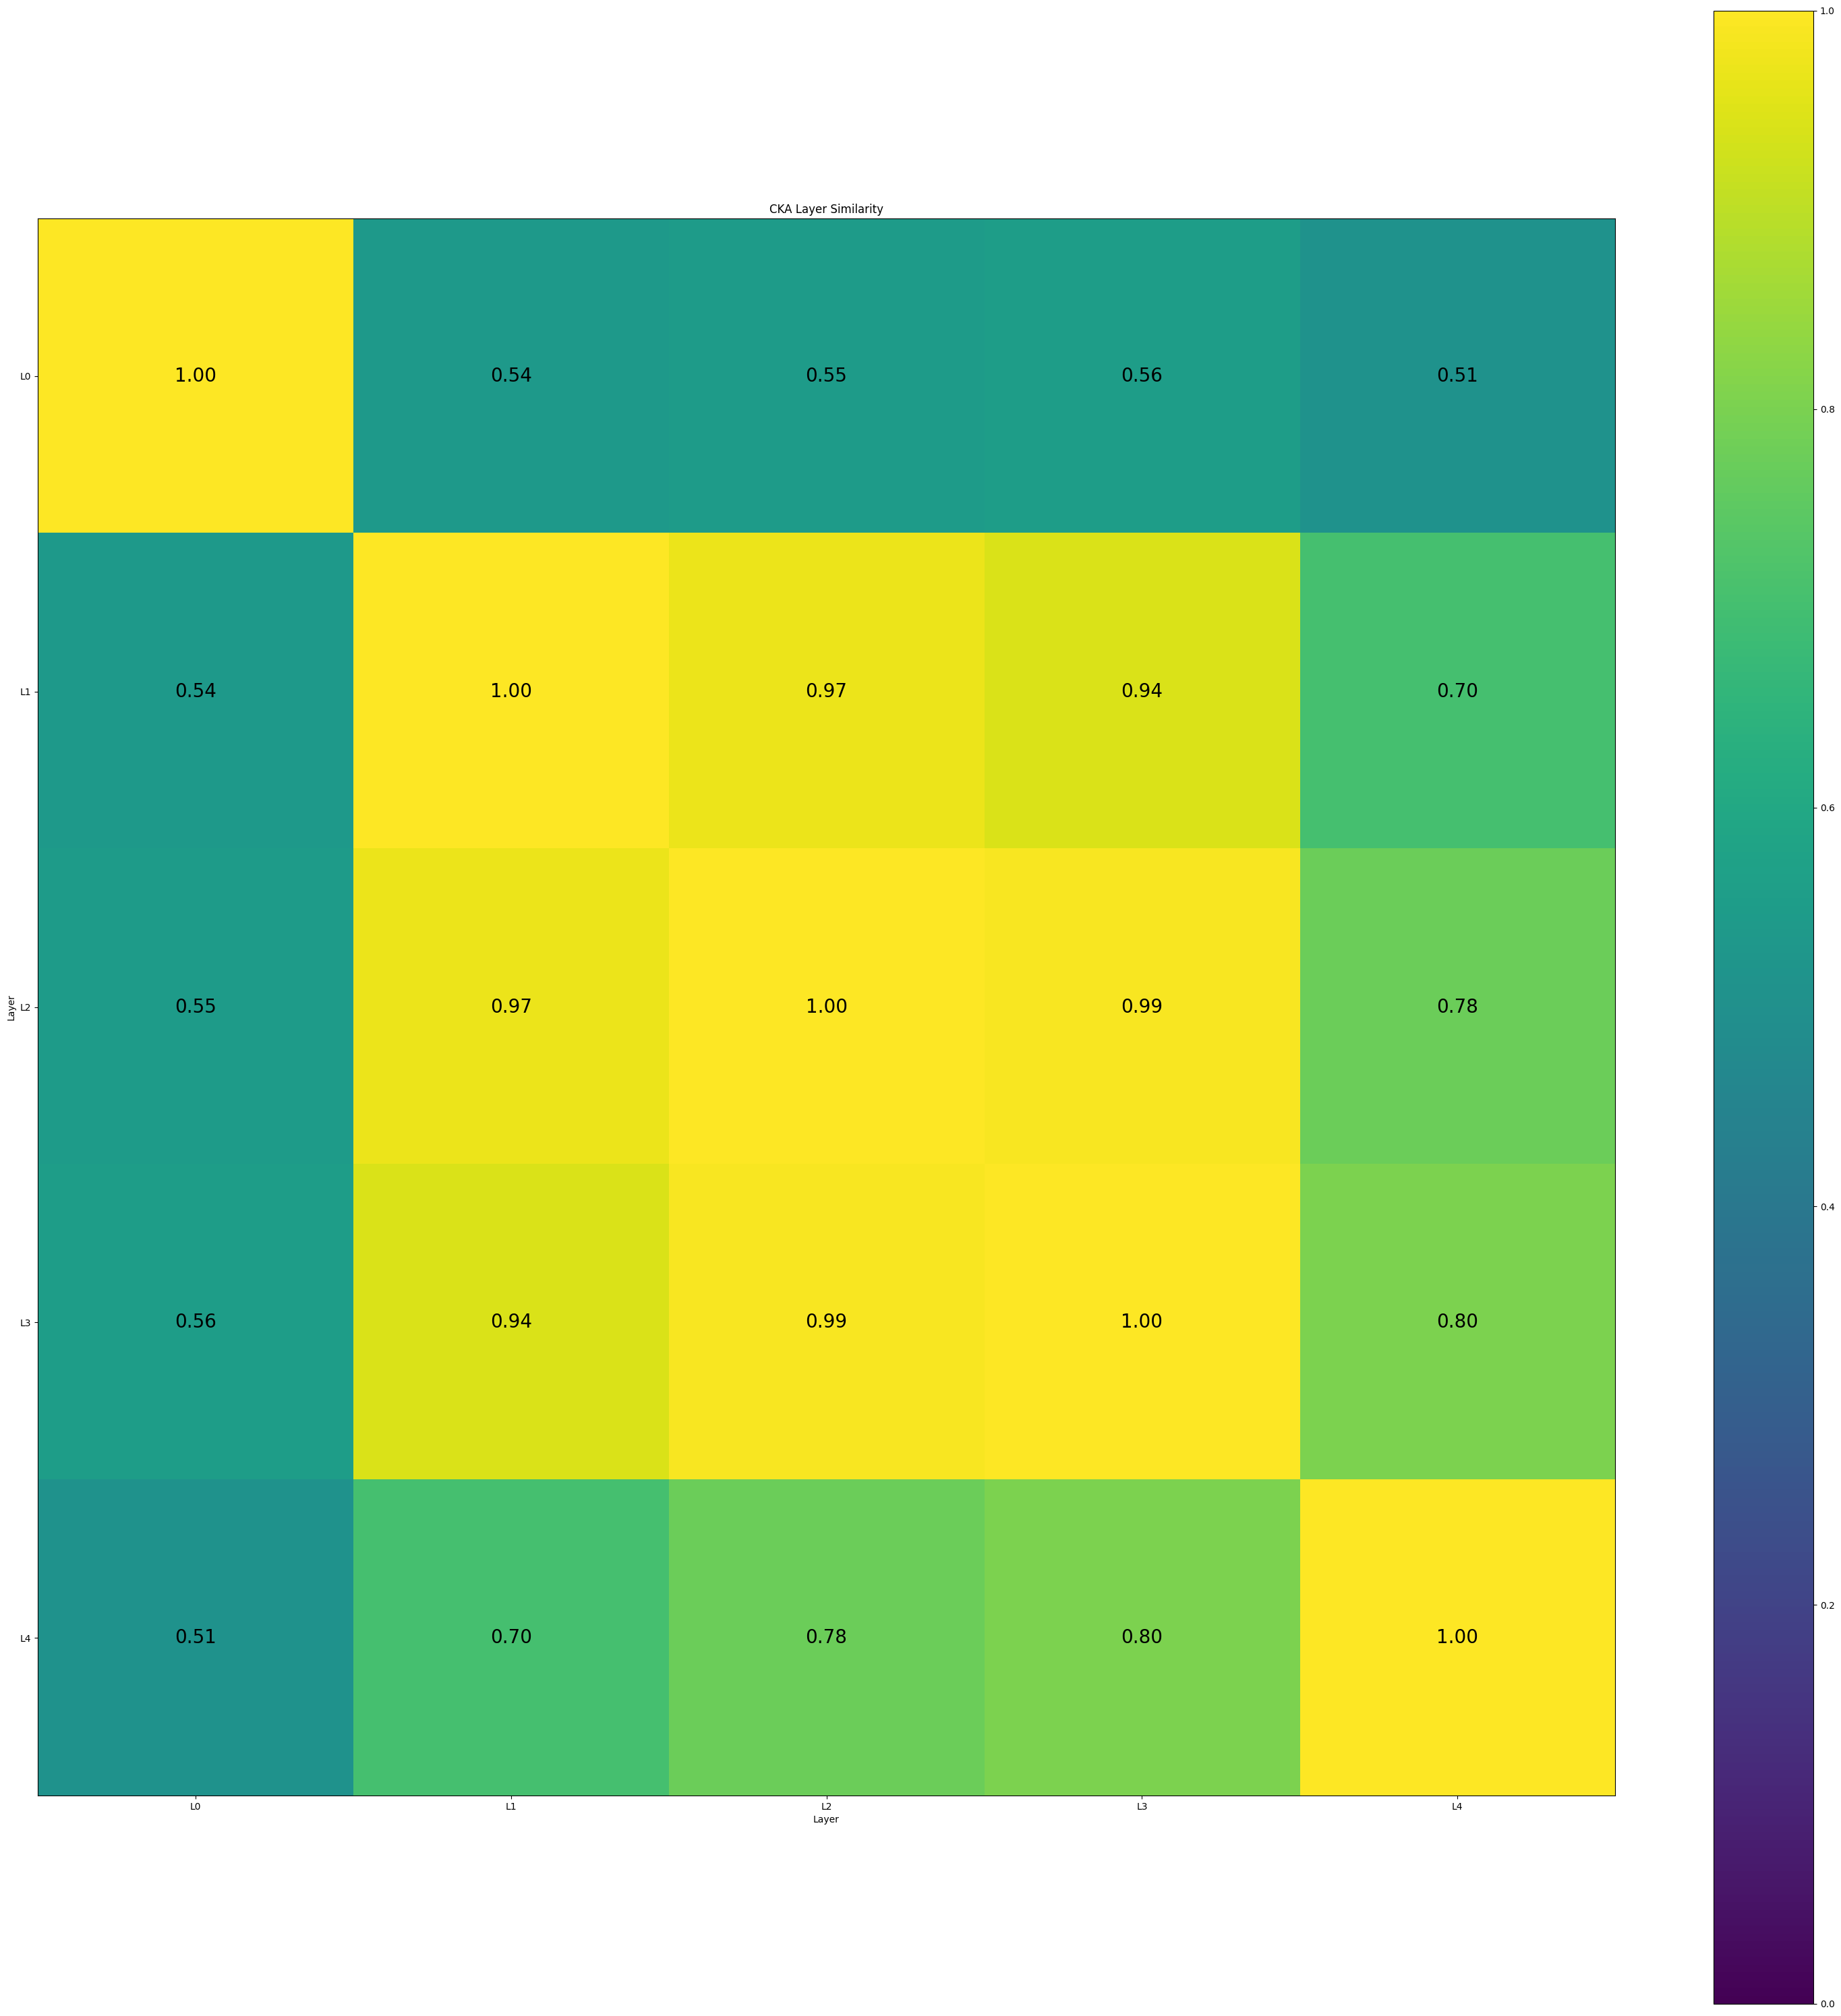

In [13]:
# chosen_module = "dit"
# chosen_module = 'vlm'
chosen_module = "vl_self_attn"

import os

hs_root = "/home/jibby/Workspace/research/prunner/attn_pi0/old/attn_gr15/hs"

hs_dir = f"{hs_root}/{chosen_module}"
# n_embs = [0, 1]
n_layers = list(range(len(os.listdir(hs_dir))))
list_hs = []
for i in n_layers:
    list_hs.append(np.load(f"{hs_dir}/layer_{i}.npy"))

cka_matrix= compute_cka_matrix(list_hs)
plot_cka_heatmap(cka_matrix)

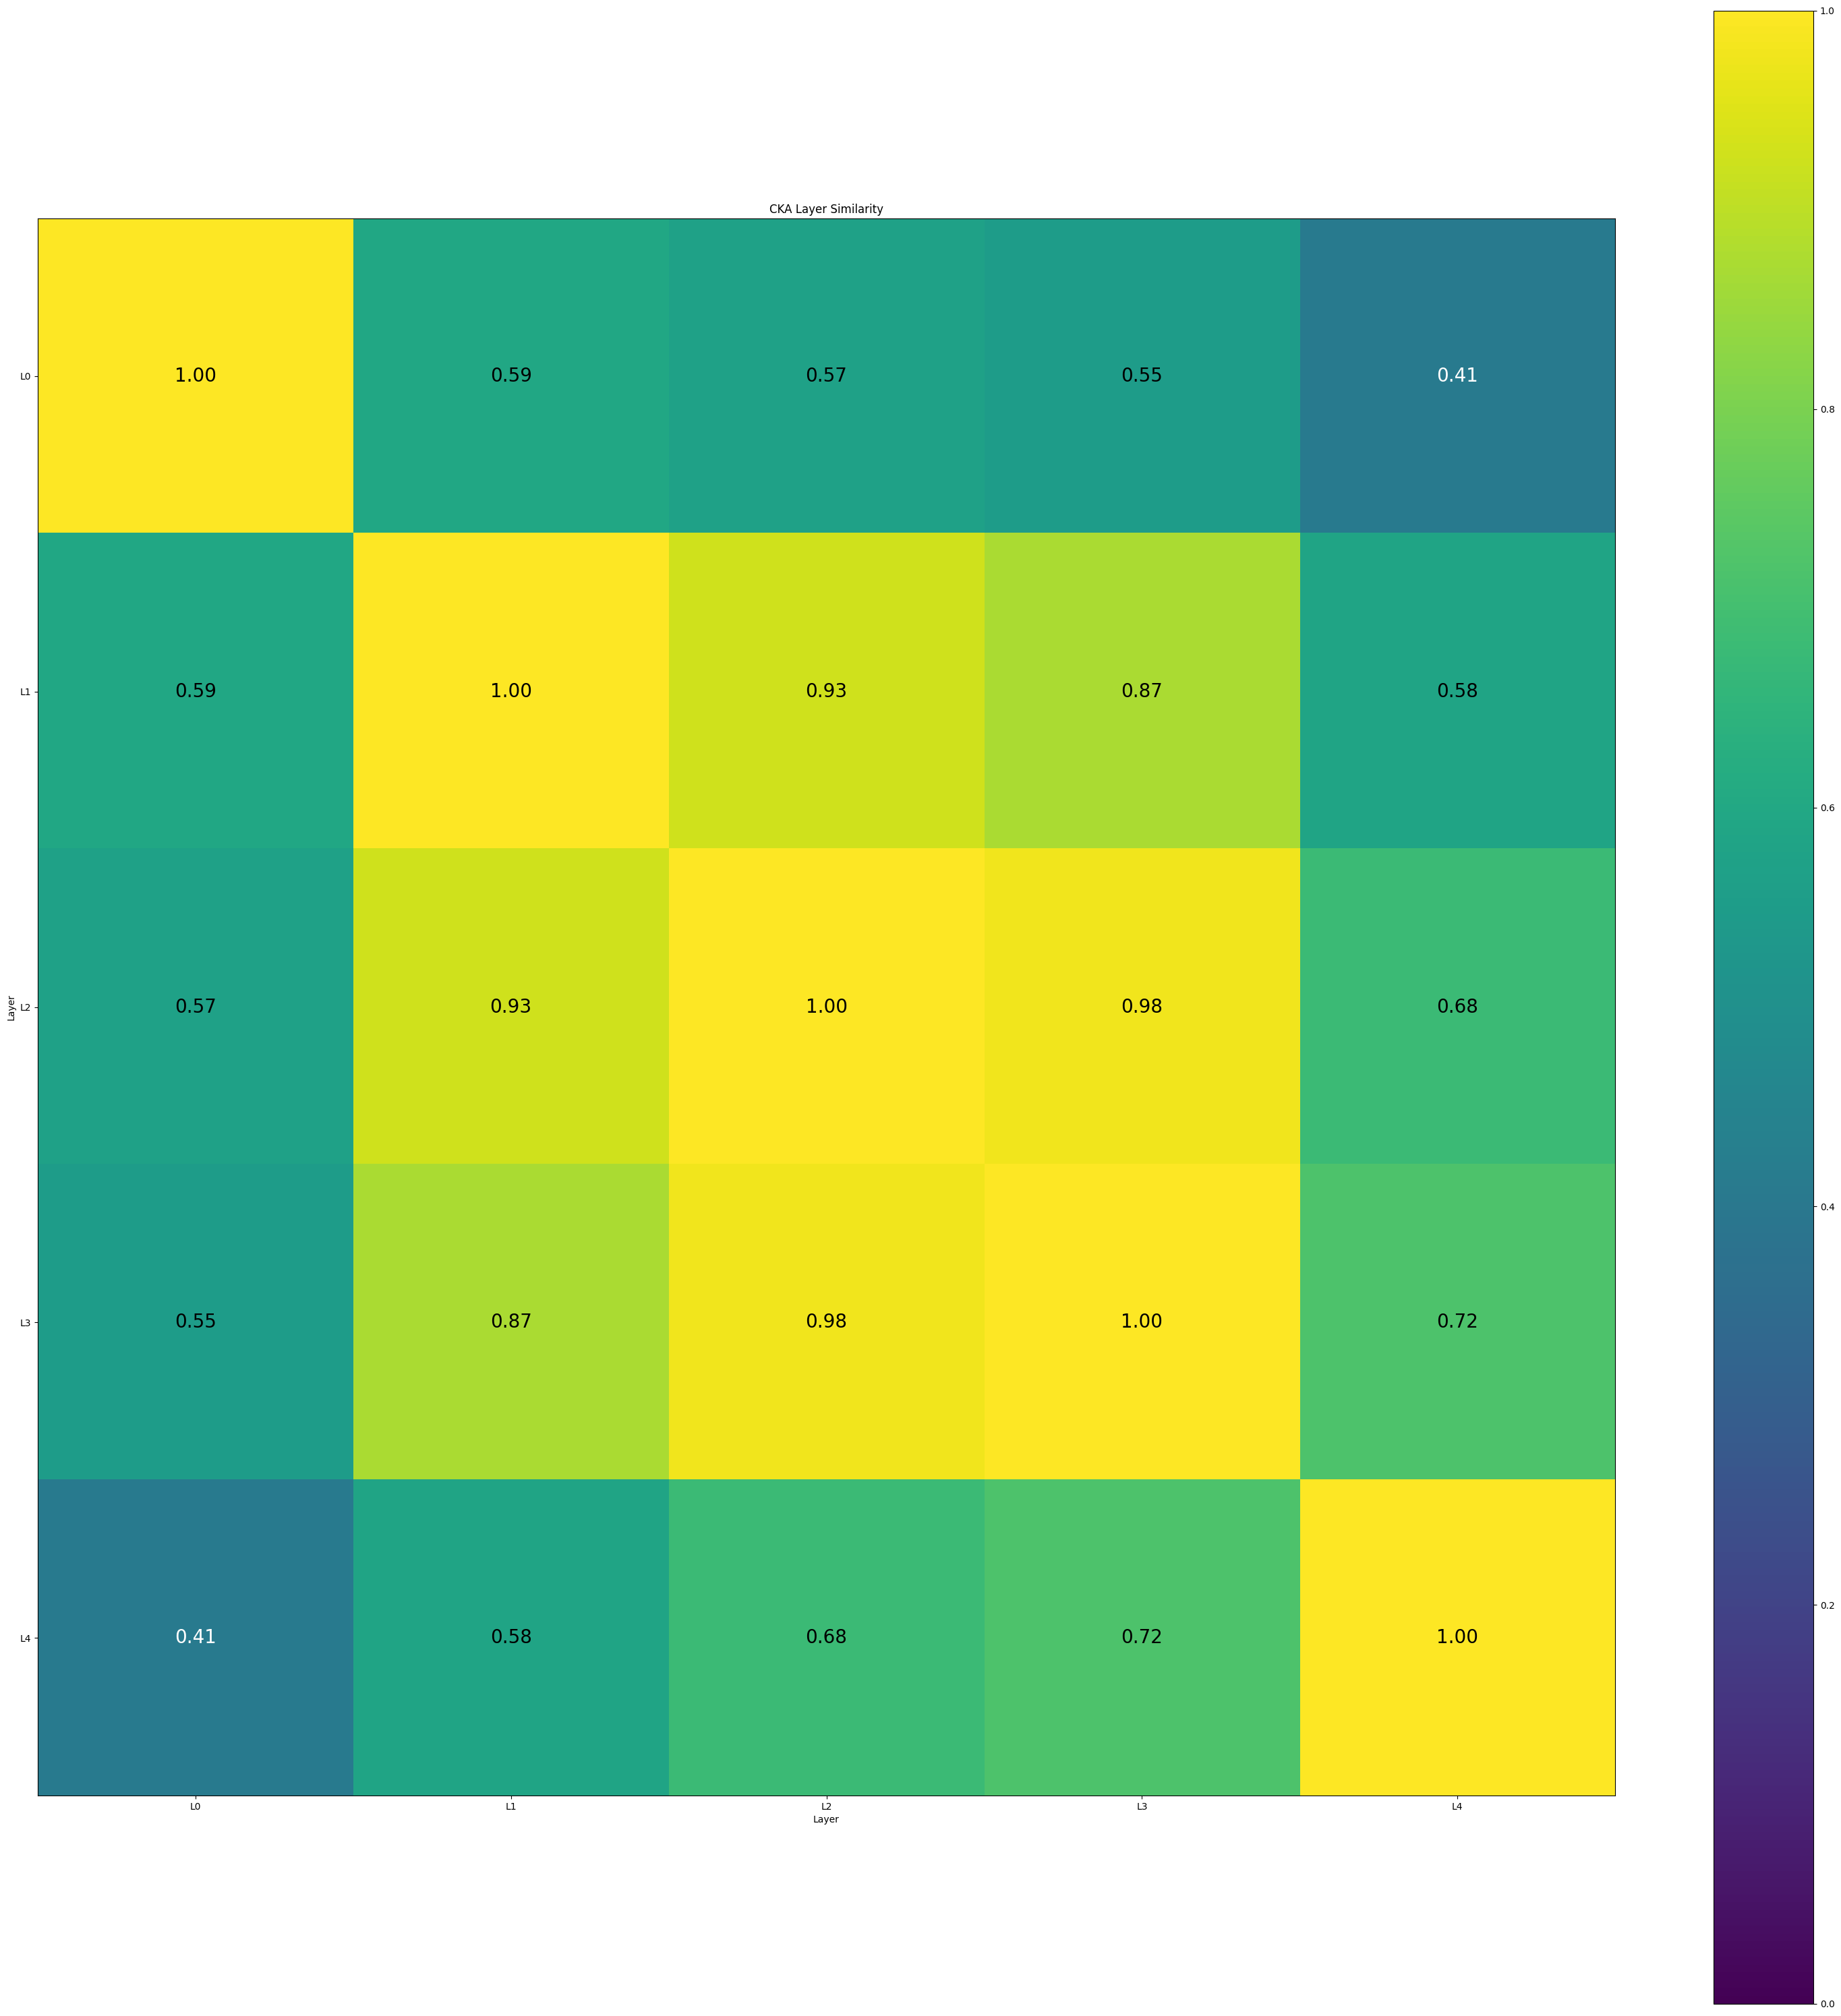

In [8]:
# chosen_module = "dit"
# chosen_module = 'vlm'
chosen_module = "vl_self_attn"

import os

hs_root = "/home/jibby/Workspace/research/prunner/attn_pi0/gr15_difference_version/attn/gr15_base/hs"

hs_dir = f"{hs_root}/{chosen_module}"
# n_embs = [0, 1]
n_layers = list(range(len(os.listdir(hs_dir))))
list_hs = []
for i in n_layers:
    list_hs.append(np.load(f"{hs_dir}/layer_{i}.npy"))

cka_matrix= compute_cka_matrix(list_hs)
plot_cka_heatmap(cka_matrix)

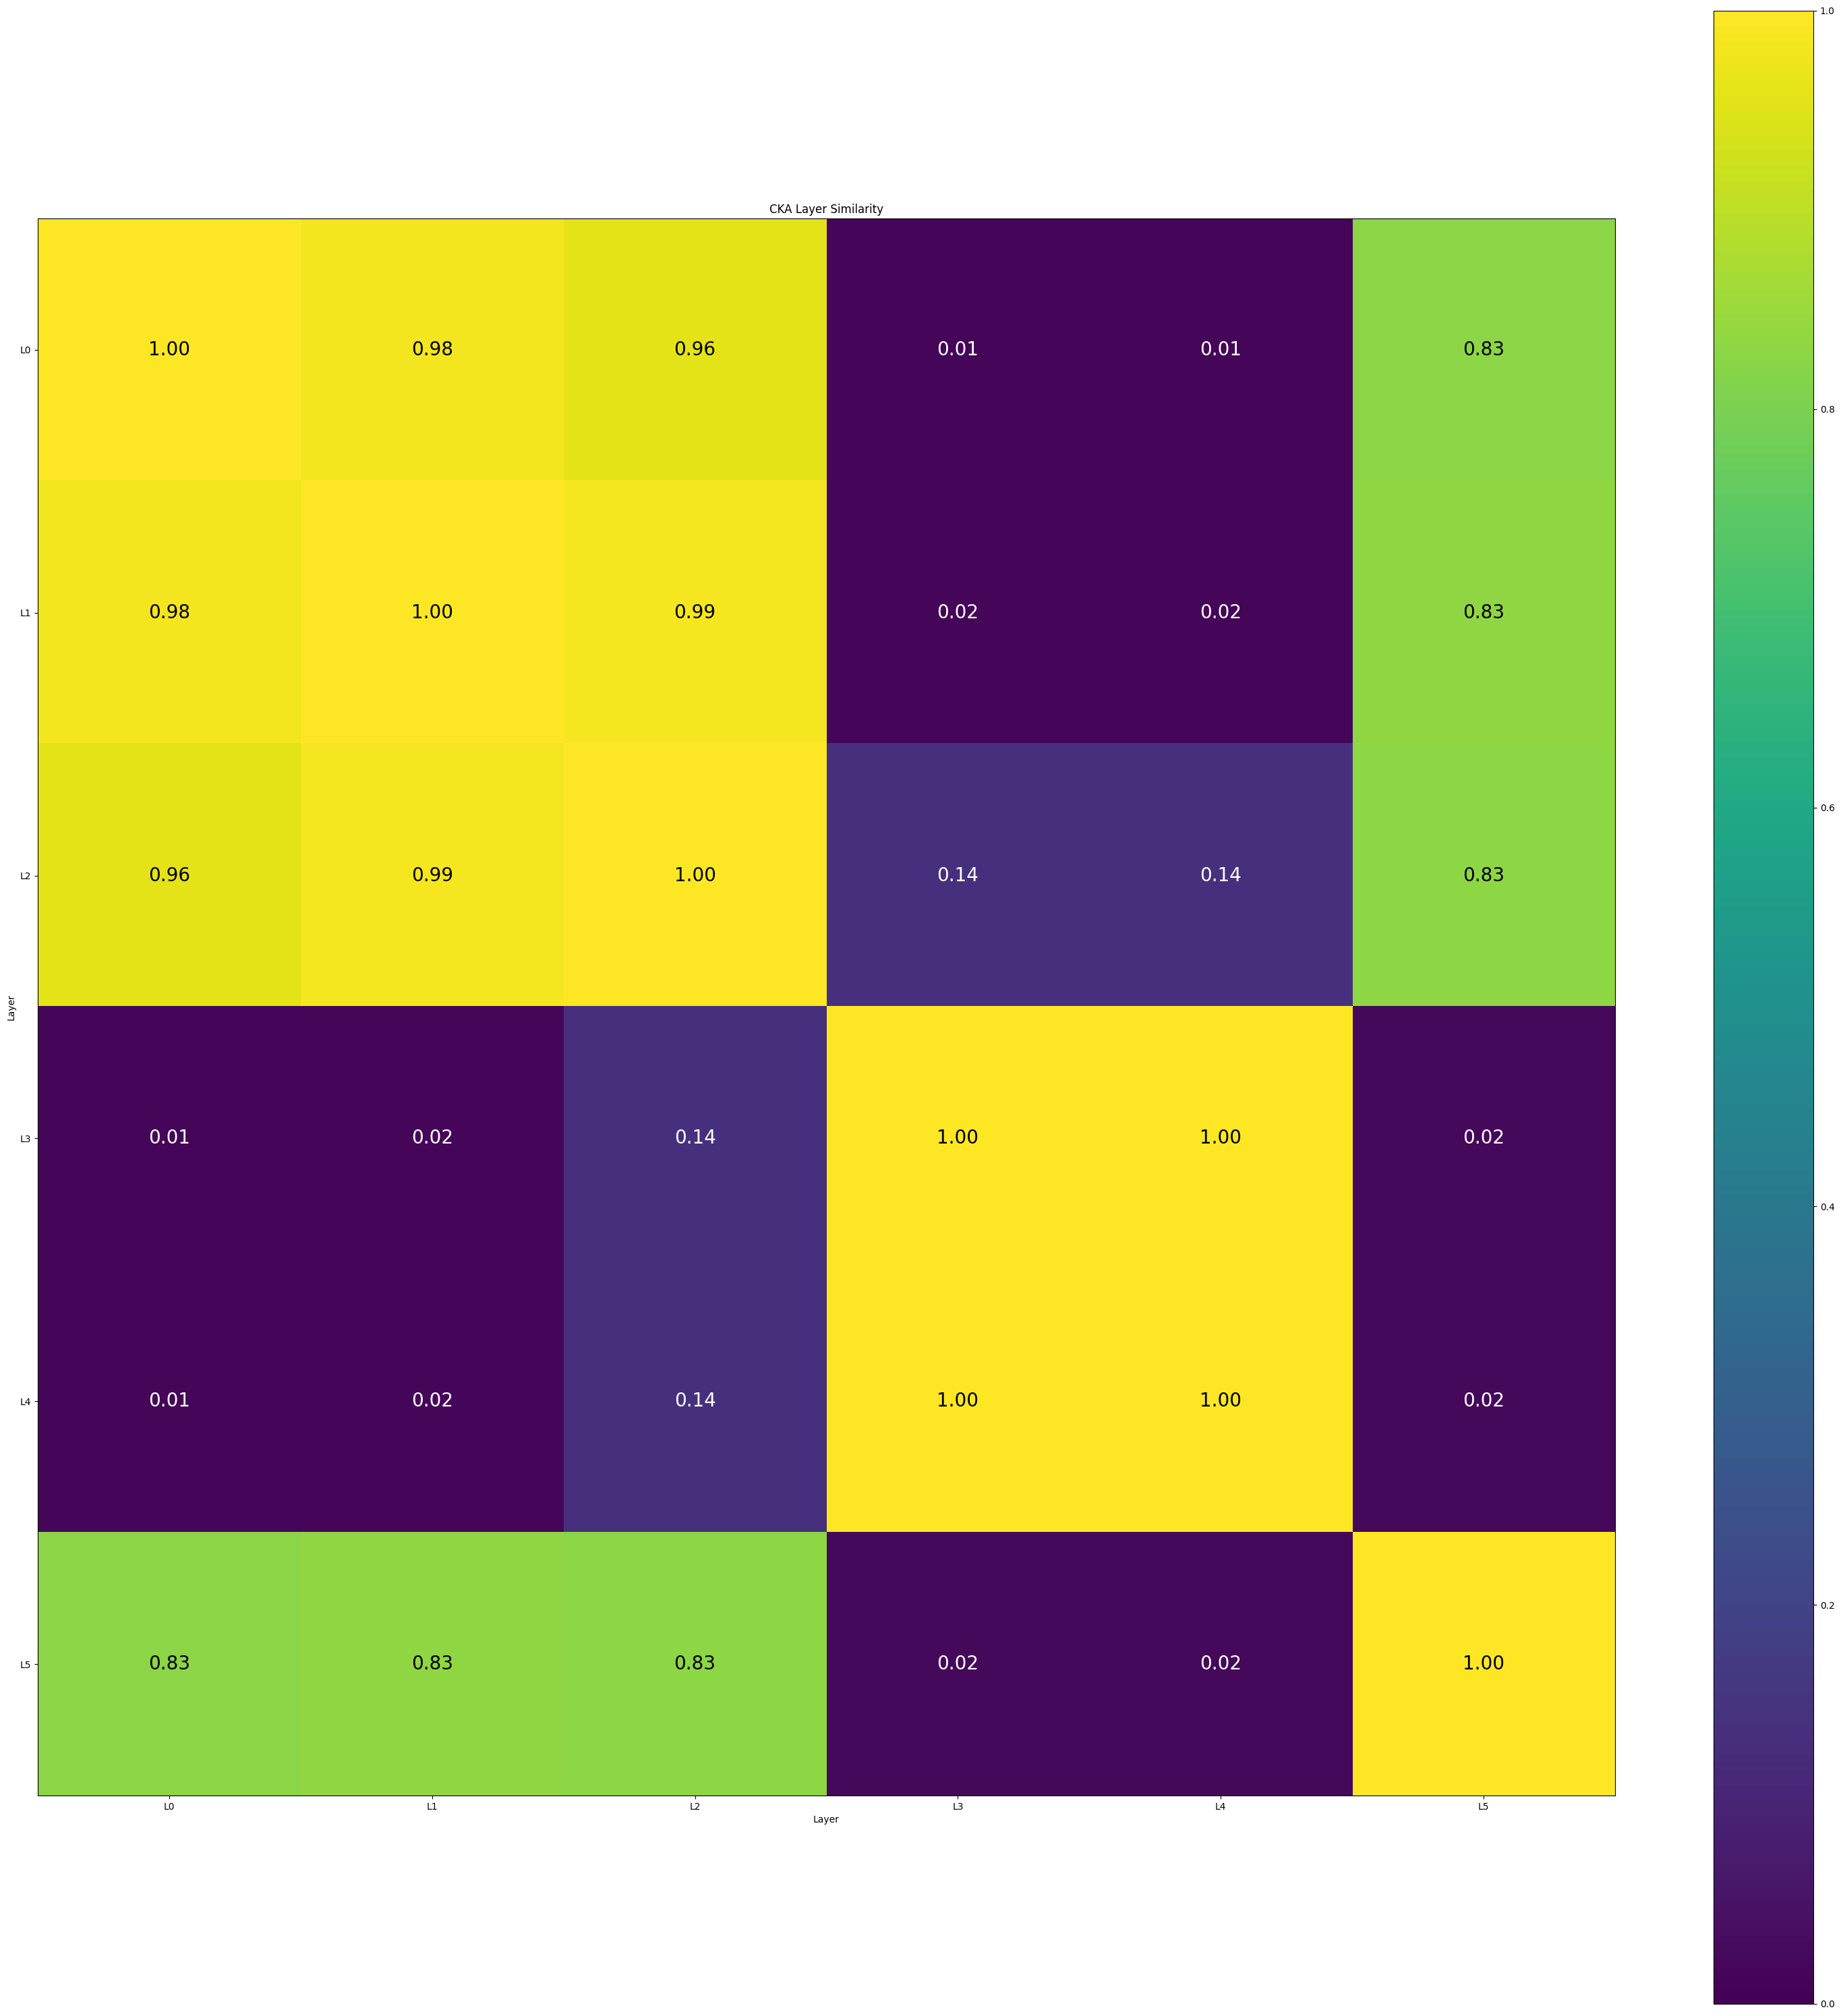

In [23]:
# chosen_module = "dit"
chosen_module = 'vlm'
# chosen_module = "vl_self_attn"

import os

hs_root = "/home/binhng/Workspace/attn_pi0/gr15_difference_version/attn/gr15_pretrained_12/hs"

hs_dir = f"{hs_root}/{chosen_module}"
# n_embs = [0, 1]
n_layers = list(range(len(os.listdir(hs_dir))))
list_hs = []
for i in n_layers:
    list_hs.append(np.load(f"{hs_dir}/layer_{i}.npy"))

cka_matrix= compute_cka_matrix(list_hs)
plot_cka_heatmap(cka_matrix)

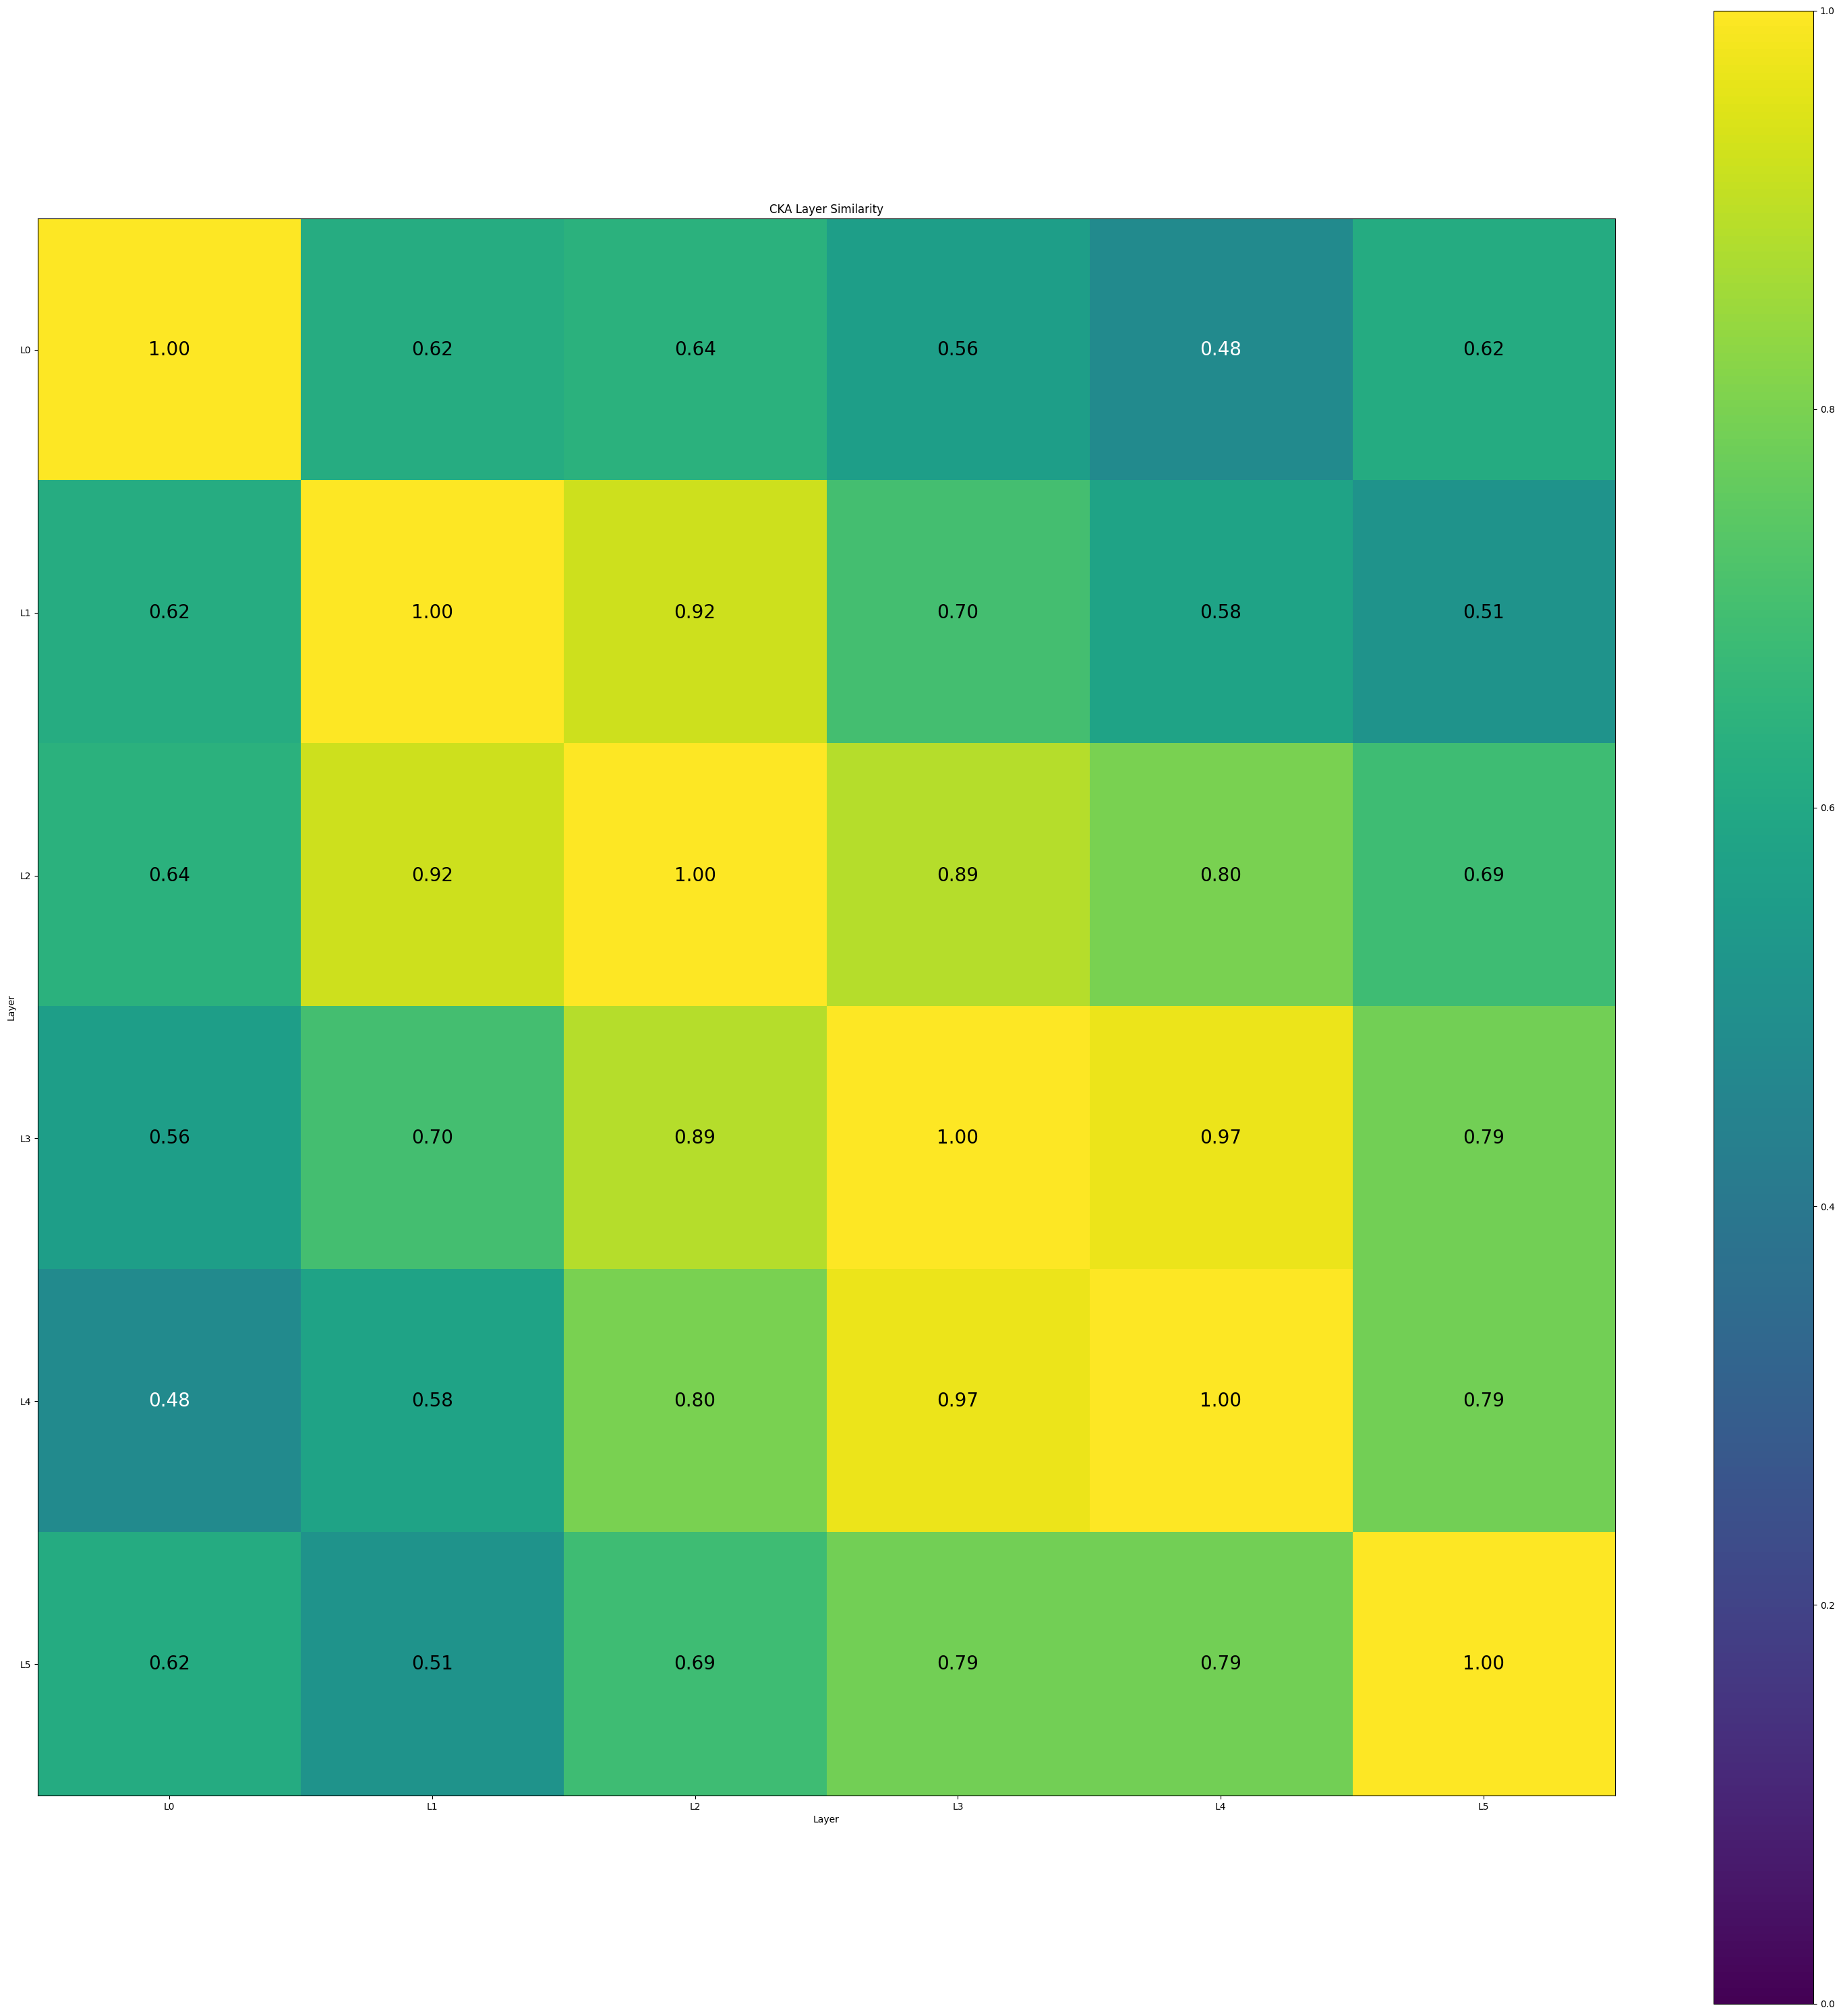

In [24]:
# chosen_module = "dit"
chosen_module = 'vlm'
# chosen_module = "vl_self_attn"

import os

hs_root = "/home/binhng/Workspace/attn_pi0/gr15_difference_version/attn/gr15_random_12/hs"

hs_dir = f"{hs_root}/{chosen_module}"
# n_embs = [0, 1]
n_layers = list(range(len(os.listdir(hs_dir))))
list_hs = []
for i in n_layers:
    list_hs.append(np.load(f"{hs_dir}/layer_{i}.npy"))

cka_matrix= compute_cka_matrix(list_hs)
plot_cka_heatmap(cka_matrix)